# EDA Trạm 2B — Topic Classification (18 Classes + Augmented FAQ)

Notebook này tổng hợp các biểu đồ chính cho báo cáo kỹ thuật Trạm 2B: độ dài văn bản, mất cân bằng lớp, và cơ cấu nguồn dữ liệu.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
FIG_DIR = BASE_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = BASE_DIR / "data" / "topic_train.json"
AUG_PATH = BASE_DIR / "data" / "topic_train_augmented.json"
MAP_PATH = BASE_DIR / "data" / "topic_label_map.json"

print("BASE_DIR:", BASE_DIR)
print("Train:", TRAIN_PATH)
print("Augmented:", AUG_PATH)
print("Label map:", MAP_PATH)

BASE_DIR: C:\Users\User\Desktop\Chatbot-Y tế
Train: C:\Users\User\Desktop\Chatbot-Y tế\data\topic_train.json
Augmented: C:\Users\User\Desktop\Chatbot-Y tế\data\topic_train_augmented.json
Label map: C:\Users\User\Desktop\Chatbot-Y tế\data\topic_label_map.json


## 1) Phân bố chiều dài văn bản (Word Count)

Mục tiêu: chứng minh `max_length=256` là hợp lý và ít gây mất mát thông tin do truncation.

In [2]:
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    topic_train = json.load(f)

df_train = pd.DataFrame(topic_train)
df_train["word_count"] = df_train["text"].fillna("").astype(str).str.split().str.len()

median_wc = float(df_train["word_count"].median())
print("Train samples:", len(df_train))
print(f"Median word count: {median_wc:.1f}")
print(f"95th percentile: {df_train['word_count'].quantile(0.95):.1f}")
print(f"Max word count: {df_train['word_count'].max():.0f}")

Train samples: 10216
Median word count: 84.0
95th percentile: 166.0
Max word count: 502


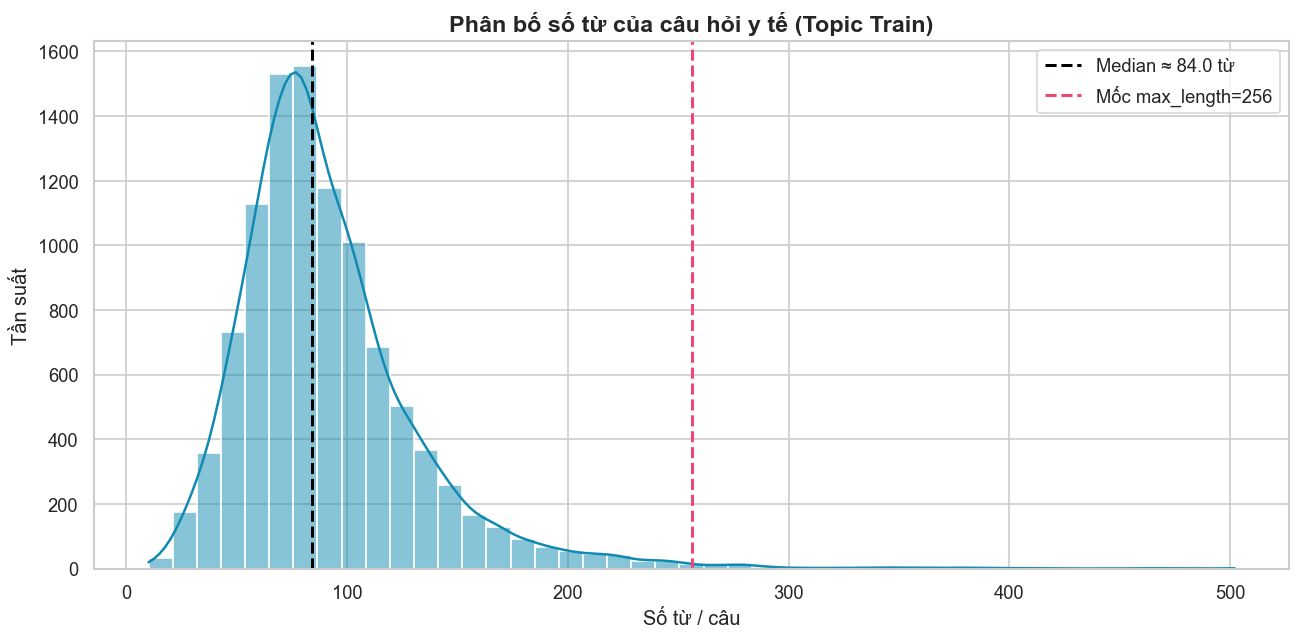

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.histplot(df_train["word_count"], bins=45, kde=True, color="#118ab2", ax=ax)
ax.set_title("Phân bố số từ của câu hỏi y tế (Topic Train)", fontsize=14, fontweight="bold")
ax.set_xlabel("Số từ / câu")
ax.set_ylabel("Tần suất")

ax.axvline(median_wc, color="black", linestyle="--", linewidth=1.8, label=f"Median ≈ {median_wc:.1f} từ")
ax.axvline(256, color="#ef476f", linestyle="--", linewidth=1.8, label="Mốc max_length=256")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "tram2b_wordcount_hist_kde.png", dpi=300, bbox_inches="tight")
plt.show()

> **💡 Insight rút ra:** Median word count thường thấp hơn đáng kể so với `max_length=256`, cho thấy cấu hình truncation hiện tại có biên an toàn tốt và ít làm mất thông tin ở phần lớn mẫu.

## 2) Class Imbalance Analysis (18 chuyên khoa)

Mục tiêu: trực quan hoá phân bố nhãn, làm nổi bật nhóm đa số vs thiểu số, và tính chỉ số mất cân bằng tổng thể.

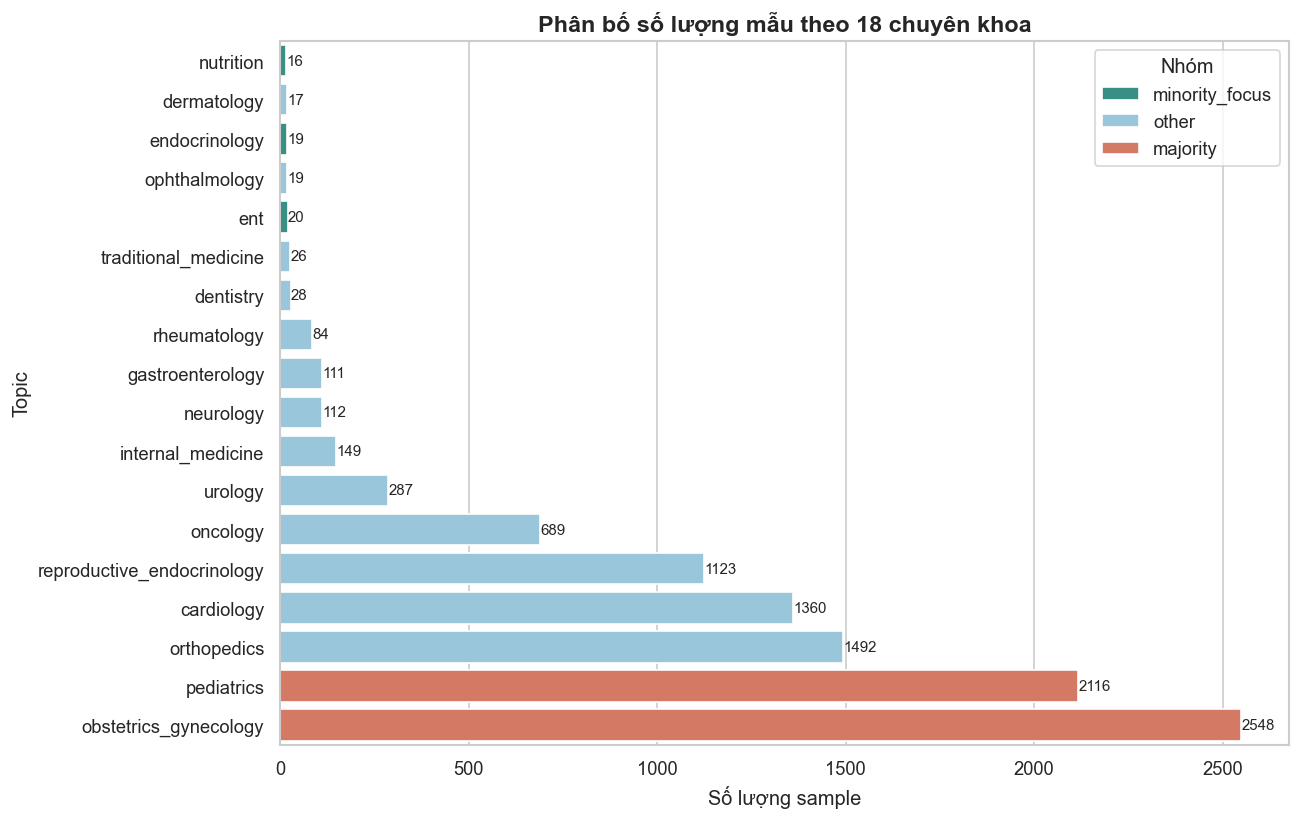

**Imbalance Ratio (max/min): 159.25x**


In [4]:
class_counts = df_train["topic"].value_counts().sort_values(ascending=True)
imbalance_ratio = class_counts.max() / max(class_counts.min(), 1)

majority_classes = {"obstetrics_gynecology", "pediatrics"}
minority_focus = {"ent", "endocrinology", "nutrition"}

plot_df = class_counts.reset_index()
plot_df.columns = ["topic", "count"]
plot_df["group"] = "other"
plot_df.loc[plot_df["topic"].isin(majority_classes), "group"] = "majority"
plot_df.loc[plot_df["topic"].isin(minority_focus), "group"] = "minority_focus"

palette = {
    "majority": "#e76f51",      # đỏ/cam
    "minority_focus": "#2a9d8f", # xanh
    "other": "#8ecae6",         # xanh nhạt
}

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=plot_df, x="count", y="topic", hue="group", dodge=False, palette=palette, ax=ax)
ax.set_title("Phân bố số lượng mẫu theo 18 chuyên khoa", fontsize=14, fontweight="bold")
ax.set_xlabel("Số lượng sample")
ax.set_ylabel("Topic")
ax.legend(title="Nhóm")

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width + 1, p.get_y() + p.get_height() / 2),
            va="center",
            fontsize=9,
        )

plt.tight_layout()
plt.savefig(FIG_DIR / "tram2b_class_imbalance_barh.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"**Imbalance Ratio (max/min): {imbalance_ratio:.2f}x**")

> **💡 Insight rút ra:** Chênh lệch max/min lớn cho thấy bài toán có tính mất cân bằng cao. Nếu chỉ tối ưu Accuracy tổng thể, mô hình rất dễ thiên lệch về các khoa đa số và bỏ qua khoa hiếm.

## 3) Source Distribution sau Augmentation

Mục tiêu: định lượng đóng góp của từng nguồn dữ liệu trong tập train augmented, bao gồm phần FAQ pseudo-label.

In [5]:
with open(AUG_PATH, "r", encoding="utf-8") as f:
    topic_aug = json.load(f)

df_aug = pd.DataFrame(topic_aug)

# Chuẩn hóa tên source để gộp nhóm trình bày cho báo cáo
def normalize_source(s: str) -> str:
    x = str(s).strip().lower()
    if "faq" in x and ("pseudo" in x or "silver" in x or "high" in x):
        return "faq_pseudo_high"
    if "vinmec" in x or x == "train_ml":
        return "vinmec"
    if "tamanh" in x or "tam_anh" in x:
        return "tamanh"
    if "alobacsi" in x:
        return "alobacsi"
    return x

df_aug["source_norm"] = df_aug["source"].fillna("unknown").map(normalize_source)
source_counts = df_aug["source_norm"].value_counts()
source_df = source_counts.reset_index()
source_df.columns = ["source", "count"]
source_df["ratio"] = source_df["count"] / source_df["count"].sum() * 100
source_df

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Chatbot-Y tế\\data\\topic_train_augmented.json'

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
bar = sns.barplot(data=source_df, x="source", y="count", palette="Set2", ax=ax)
ax.set_title("Tỷ trọng nguồn dữ liệu trong topic_train_augmented", fontsize=14, fontweight="bold")
ax.set_xlabel("Nguồn")
ax.set_ylabel("Số lượng sample")

for p, ratio in zip(ax.patches, source_df["ratio"]):
    ax.annotate(
        f"{int(p.get_height())}\n({ratio:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "tram2b_source_distribution_bar.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    source_df["count"],
    labels=source_df["source"],
    autopct="%1.1f%%",
    startangle=100,
    colors=sns.color_palette("Set2", n_colors=len(source_df)),
    textprops={"fontsize": 10},
)
ax.set_title("Source Mix (Pie) — topic_train_augmented", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "tram2b_source_distribution_pie.png", dpi=300, bbox_inches="tight")
plt.show()

> **💡 Insight rút ra:** Tỷ lệ nguồn dữ liệu cho thấy augment FAQ đã bổ sung thêm mẫu mà không thay thế dữ liệu gốc. Đây là bằng chứng định lượng cho chiến lược “rescue minority classes” trong báo cáo kỹ thuật.